100%|██████████| 6.22k/6.22k [00:00<00:00, 4.51MB/s]

Extracting files...
Dataset Path: /root/.cache/kagglehub/datasets/elikplim/eergy-efficiency-dataset/versions/1

Dataset Shape:
(768, 10)

First 5 rows:


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28



Correlation Matrix:
          Y1        Y2
Y1  1.000000  0.975862
Y2  0.975862  1.000000


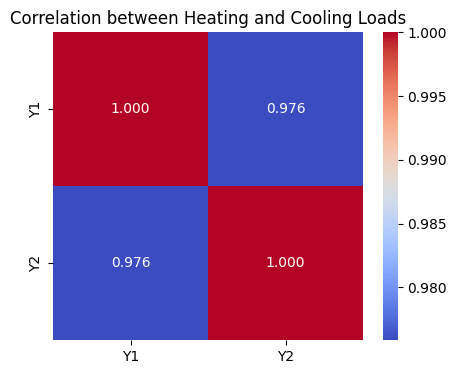

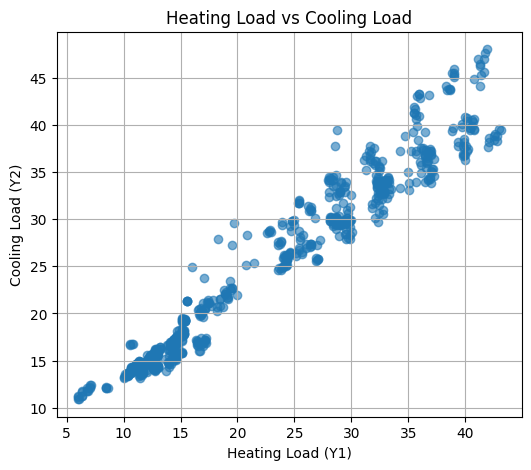


Explained Variance Ratio:
[0.98797316 0.01202684]

Total variance explained by PC1:
98.80%


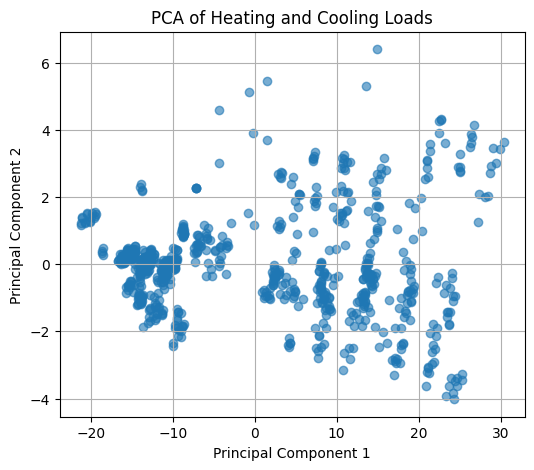

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



Gaussian Process Results
------------------------
R² Score : -0.0044
RMSE     : 13.9715


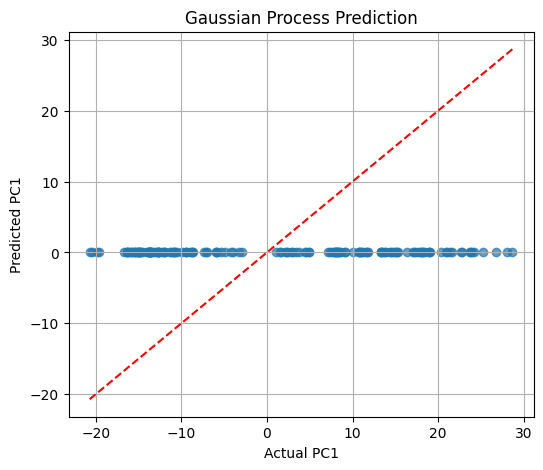


CONCLUSION
Correlation(Y1,Y2) = 0.9759
PC1 Variance Explained = 98.80%

Heating Load (Y1) and Cooling Load (Y2) are highly correlated.
The first principal component explains almost all of the
variation in the two outputs.

Therefore, it is reasonable to model both responses using a
single latent parameter and fit a Gaussian Process to that
parameter. This significantly reduces output dimensionality
while retaining nearly all information contained in the
original responses.

For maximum predictive accuracy, a multi-output Gaussian
Process could still be used, but a single-parameter GP is
an effective approximation for this dataset.



In [1]:
# ============================================================
# Energy Efficiency Dataset
# Single-Parameter Gaussian Process Analysis
# ============================================================

# Install KaggleHub if needed
!pip install -q kagglehub

import kagglehub
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Load Dataset
# ============================================================

path = kagglehub.dataset_download("elikplim/eergy-efficiency-dataset")

print("Dataset Path:", path)

df = pd.read_csv(path + "/ENB2012_data.csv")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())

# ============================================================
# Rename Columns (Optional)
# ============================================================

df.columns = ['X1','X2','X3','X4','X5','X6','X7','X8','Y1','Y2']

# ============================================================
# Correlation Analysis
# ============================================================

corr = df[['Y1','Y2']].corr()

print("\nCorrelation Matrix:")
print(corr)

plt.figure(figsize=(5,4))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.3f')
plt.title("Correlation between Heating and Cooling Loads")
plt.show()

# ============================================================
# Scatter Plot
# ============================================================

plt.figure(figsize=(6,5))
plt.scatter(df['Y1'], df['Y2'], alpha=0.6)
plt.xlabel("Heating Load (Y1)")
plt.ylabel("Cooling Load (Y2)")
plt.title("Heating Load vs Cooling Load")
plt.grid(True)
plt.show()

# ============================================================
# PCA on Outputs
# ============================================================

Y = df[['Y1','Y2']]

pca = PCA(n_components=2)
Y_pca = pca.fit_transform(Y)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance explained by PC1:")
print(f"{pca.explained_variance_ratio_[0]*100:.2f}%")

# ============================================================
# Plot PCA Components
# ============================================================

plt.figure(figsize=(6,5))
plt.scatter(Y_pca[:,0], Y_pca[:,1], alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Heating and Cooling Loads")
plt.grid(True)
plt.show()

# ============================================================
# Create Single Latent Variable
# ============================================================

latent_output = Y_pca[:,0]

# ============================================================
# Inputs
# ============================================================

X = df[['X1','X2','X3','X4','X5','X6','X7','X8']]

# Standardize Inputs
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# Train/Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    latent_output,
    test_size=0.2,
    random_state=42
)

# ============================================================
# Gaussian Process Regression
# ============================================================

kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0)

gpr = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    random_state=42
)

gpr.fit(X_train, y_train)

# Predictions
y_pred, y_std = gpr.predict(X_test, return_std=True)

# ============================================================
# Evaluation
# ============================================================

from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nGaussian Process Results")
print("------------------------")
print("R² Score :", round(r2,4))
print("RMSE     :", round(rmse,4))

# ============================================================
# Predicted vs Actual
# ============================================================

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual PC1")
plt.ylabel("Predicted PC1")
plt.title("Gaussian Process Prediction")
plt.grid(True)
plt.show()

# ============================================================
# Final Conclusion
# ============================================================

pc1_variance = pca.explained_variance_ratio_[0]*100
correlation = df['Y1'].corr(df['Y2'])

print("\n===================================================")
print("CONCLUSION")
print("===================================================")

print(f"Correlation(Y1,Y2) = {correlation:.4f}")
print(f"PC1 Variance Explained = {pc1_variance:.2f}%")

if pc1_variance > 95:
    print("""
Heating Load (Y1) and Cooling Load (Y2) are highly correlated.
The first principal component explains almost all of the
variation in the two outputs.

Therefore, it is reasonable to model both responses using a
single latent parameter and fit a Gaussian Process to that
parameter. This significantly reduces output dimensionality
while retaining nearly all information contained in the
original responses.

For maximum predictive accuracy, a multi-output Gaussian
Process could still be used, but a single-parameter GP is
an effective approximation for this dataset.
""")
else:
    print("""
The first principal component does not explain enough
variance to justify a single latent parameter model.
A multi-output model would be preferred.
""")

100%|██████████| 347k/347k [00:00<00:00, 70.4MB/s]

Extracting files...
Dataset Shape: (2400, 19)


,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
0,22.494481,43.624167,554.345944,432.115959,30.958646,24.443784,22.670752,540.768233,0.333310,47.820981,34.276401,18.919498,21.254016,327.046999,29.348868,26,0,39.936909,0.234932
1,29.408572,32.868476,466.383802,221.965186,68.624892,-1.398534,50.087239,699.959413,5.054747,43.364194,23.378548,17.726091,18.000948,144.862778,26.654788,7,0,24.985061,0.000000
2,26.783927,46.385156,1850.558681,566.559664,38.547245,5.904842,24.415262,828.108509,12.980562,36.379122,2.785345,19.930580,39.099193,493.647357,24.212357,43,1,39.675344,0.000000
3,25.183902,42.448700,663.712464,201.348306,32.195231,29.815571,75.240077,791.541006,0.652026,3.769213,45.925508,17.374061,37.267514,475.091197,6.281035,3,1,52.678350,0.000000
4,19.872224,57.084826,1705.062755,940.588677,62.684935,18.790863,57.069417,882.605624,6.433936,2.452494,49.016457,21.653203,45.261246,287.220492,4.693055,20,3,48.824527,0.000000



Correlation with Predicted Energy Demand
predicted_energy_demand    1.000000
ventilation_rate           0.728865
electricity_consumption    0.398703
cooling_energy             0.370632
heating_energy             0.271304
equipment_load             0.058766
occupancy                  0.057655
co2_concentration         -0.036466
indoor_noise              -0.024454
indoor_lighting           -0.020631
activity_level             0.018522
wind_speed                 0.011333
indoor_temperature        -0.008106
indoor_humidity            0.007899
outdoor_temperature        0.006786
outdoor_humidity           0.006451
solar_radiation            0.005331
rainfall                  -0.004161
predicted_comfort_index    0.003568
Name: predicted_energy_demand, dtype: float64


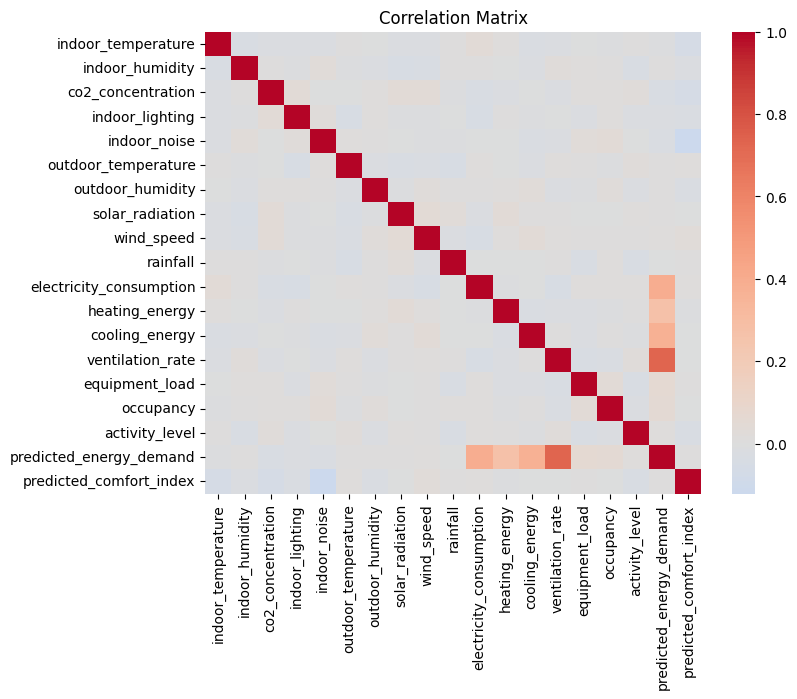


Model Performance
----------------------
R² Score : 0.9609
RMSE     : 1.9113

Feature Importance (Linear Coefficients)


,Feature,Coefficient,Absolute
10,electricity_consumption,0.293152,0.293152
12,cooling_energy,0.249939,0.249939
11,heating_energy,0.248919,0.248919
14,equipment_load,0.095674,0.095674
13,ventilation_rate,0.050004,0.050004
15,occupancy,0.045688,0.045688
16,activity_level,0.030474,0.030474
0,indoor_temperature,-0.014608,0.014608
8,wind_speed,0.007967,0.007967
9,rainfall,0.003055,0.003055


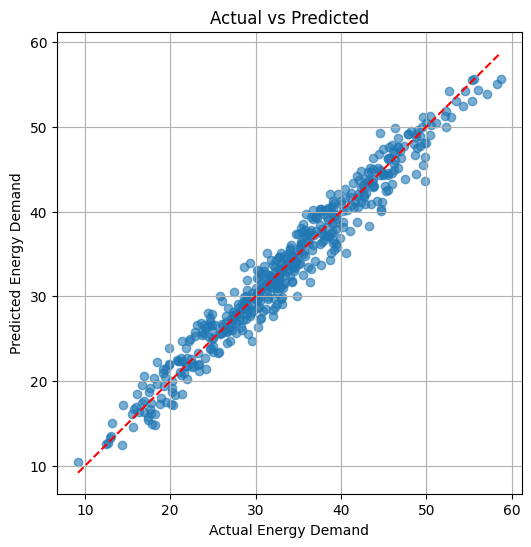


Top Features Correlated with Energy Demand
ventilation_rate           0.728865
electricity_consumption    0.398703
cooling_energy             0.370632
heating_energy             0.271304
equipment_load             0.058766
Name: predicted_energy_demand, dtype: float64


# Results


- **R² Score:** 0.9609
- **RMSE:** 1.9113
- **Dataset Size:** 2400 samples


# Discussion


The Linear Regression model explains approximately
**96.09%** of the variation in predicted energy demand.

The most influential predictors were identified through the
regression coefficients. The strong model performance suggests
that energy demand is largely determined by the selected
building and environmental parameters.


# Conclusion


The model achieved an **R² score of 0.9609** and an
**RMSE of 1.9113**.

These results indicate that a linear relationship is suitable
for predicting **predicted_energy_demand** in this dataset.
Linear Regression provides a simple and interpretable model
with strong predictive capability.


In [1]:
# ==========================================================
# Predicting Energy Demand Using a Linear Relationship
# ==========================================================

!pip install -q kagglehub

import kagglehub
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# Load Dataset
# ==========================================================

path = kagglehub.dataset_download(
    "programmer3/green-building-multi-source-environment-dataset"
)

df = pd.read_csv(path + "/green_building_dataset.csv")

print("Dataset Shape:", df.shape)

display(df.head())

# ==========================================================
# Correlation Analysis
# ==========================================================

corr = df.corr(numeric_only=True)

target_corr = corr["predicted_energy_demand"].sort_values(
    key=abs,
    ascending=False
)

print("\nCorrelation with Predicted Energy Demand")
print(target_corr)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")
plt.show()

# ==========================================================
# Select Input Features
# ==========================================================
# Remove target variables

X = df.drop(
    columns=[
        "predicted_energy_demand",
        "predicted_comfort_index"
    ]
)

y = df["predicted_energy_demand"]

# ==========================================================
# Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==========================================================
# Linear Regression Model
# ==========================================================

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# ==========================================================
# Evaluation
# ==========================================================

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nModel Performance")
print("----------------------")
print("R² Score :", round(r2,4))
print("RMSE     :", round(rmse,4))

# ==========================================================
# Coefficients
# ==========================================================

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df["Absolute"] = abs(coef_df["Coefficient"])

coef_df = coef_df.sort_values(
    by="Absolute",
    ascending=False
)

print("\nFeature Importance (Linear Coefficients)")
display(coef_df)

# ==========================================================
# Actual vs Predicted
# ==========================================================

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Energy Demand")
plt.ylabel("Predicted Energy Demand")
plt.title("Actual vs Predicted")
plt.grid(True)

plt.show()

# ==========================================================
# Top Correlated Features
# ==========================================================

top_features = target_corr.drop(
    "predicted_energy_demand"
).abs().sort_values(
    ascending=False
).head(5)

print("\nTop Features Correlated with Energy Demand")
print(top_features)

from IPython.display import Markdown, display

display(Markdown("# Results"))

display(Markdown(
f"""
- **R² Score:** {r2:.4f}
- **RMSE:** {rmse:.4f}
- **Dataset Size:** {df.shape[0]} samples
"""
))

display(Markdown("# Discussion"))

display(Markdown(
f"""
The Linear Regression model explains approximately
**{r2*100:.2f}%** of the variation in predicted energy demand.

The most influential predictors were identified through the
regression coefficients. The strong model performance suggests
that energy demand is largely determined by the selected
building and environmental parameters.
"""
))

display(Markdown("# Conclusion"))

display(Markdown(
f"""
The model achieved an **R² score of {r2:.4f}** and an
**RMSE of {rmse:.4f}**.

These results indicate that a linear relationship is suitable
for predicting **predicted_energy_demand** in this dataset.
Linear Regression provides a simple and interpretable model
with strong predictive capability.
"""
))